In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [9]:
# matrix of moments for different order
def compute_scaling_parameters(matrix_max, vec_pdt, vec_order):
  # matrix_max: 2D array (time, pdt)
  # vec_pdt: list or array of time scales
  # vec_order: list or array of moment orders
  n_pdt = len(vec_pdt)
  n_order = len(vec_order)
  
  # Initialize moment matrix
  moment_mat = np.empty((n_pdt,n_order), dtype=np.float32)

  # STEP 1: compute moments for different orders
  for i_pdt in range(n_pdt):
    pdt = vec_pdt[i_pdt]
    max_vec = matrix_max[:, i_pdt]
    for i_order in range(n_order):
      order = vec_order[i_order]
      moment_mat[i_pdt, i_order] = np.nanmean(max_vec**order)
  
  # STEP 2: apply linear regressions log(E_h^k) ~ a + kq*log(h) for each order
  kq = np.empty(n_order, dtype=np.float32)
  for i_order in range(n_order):
    order = vec_order[i_order]
    log_moments = np.log(moment_mat[:, i_order])
    log_pdt = np.log(vec_pdt)
    coeffs = np.polyfit(log_pdt, log_moments, 1)
    kq[i_order] = coeffs[0]

  # STEP 3: apply linear regression  kq ~ k
  reg_coeffs = np.polyfit(vec_order, kq, 1)
  scaling_parameter = -reg_coeffs[0]

  return scaling_parameter

In [10]:
# example of application of simple scaling for one spatial scale
# return scaling parameter for each grid cell

# choose one spatial scale
tagSS = 'S1'

# fill array max
ds = xr.load_dataset('D:/CNRM_ERA5/CNRM_ERA5_ALADIN_max_scale_'+tagSS+'.nc', 
                     engine='netcdf4')

# array of maxima for the different years, temporal scales, and coordinates
arraymax = ds.maxpr.values

C:\Users\eving\AppData\Local\Temp\ipykernel_8620\317116224.py:8: FutureWarning: In a future version, xarray will not decode the variable 'timescale' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.load_dataset('D:/CNRM_ERA5/CNRM_ERA5_ALADIN_max_scale_'+tagSS+'.nc',


test and illustrate simple scaling approach for one grid cell

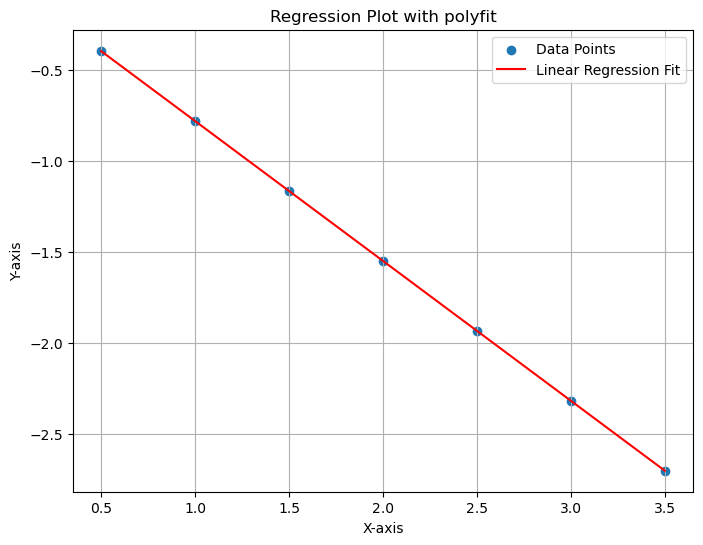

In [11]:
vec_order = np.arange(0.5, 4, 0.5)
n_order = len(vec_order)

lenx = arraymax.shape[2]
leny = arraymax.shape[3]

vec_pdt=[1,3,6,12,24,72]

matrix_max = arraymax[:,:,10,10]

# matrix_max: 2D array (time, pdt)
  # vec_pdt: list or array of time scales
  # vec_order: list or array of moment orders
n_pdt = len(vec_pdt)
n_order = len(vec_order)

# Initialize moment matrix
moment_mat = np.empty((n_pdt,n_order), dtype=np.float32)

# STEP 1: compute moments for different orders
for i_pdt in range(n_pdt):
  pdt = vec_pdt[i_pdt]
  max_vec = matrix_max[:, i_pdt]
  for i_order in range(n_order):
      order = vec_order[i_order]
      moment_mat[i_pdt, i_order] = np.nanmean(max_vec**order)

# STEP 2: apply linear regressions log(E_h^k) ~ a + kq*log(h) for each order
kq = np.empty(n_order, dtype=np.float32)
for i_order in range(n_order):
  order = vec_order[i_order]
  log_moments = np.log(moment_mat[:, i_order])
  log_pdt = np.log(vec_pdt)
  coeffs = np.polyfit(log_pdt, log_moments, 1)
  kq[i_order] = coeffs[0]

# STEP 3: apply linear regression  kq ~ k
reg_coeffs = np.polyfit(vec_order, kq, 1)
scaling_parameter = -reg_coeffs[0]

polynomial_function = np.poly1d(reg_coeffs)

# Generate points for the fitted line
x_fit = np.linspace(min(vec_order), max(vec_order), 100)
y_fit = polynomial_function(x_fit)

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(vec_order, kq, label='Data Points')
plt.plot(x_fit, y_fit, color='red', label='Linear Regression Fit')
plt.title('Regression Plot with polyfit')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
vec_order = np.arange(0.5, 4, 0.5)
n_order = len(vec_order)

lenx = arraymax.shape[2]
leny = arraymax.shape[3]

vec_pdt=[1,3,6,12,24,72]

matrix_scale_parameter = np.empty((lenx,leny), dtype=np.float32)

for ix in range(lenx):
    for iy in range(leny):
        matrix_max = arraymax[:,:,ix,iy]
        matrix_scale_parameter[ix,iy] = compute_scaling_parameters(matrix_max, vec_pdt, vec_order)


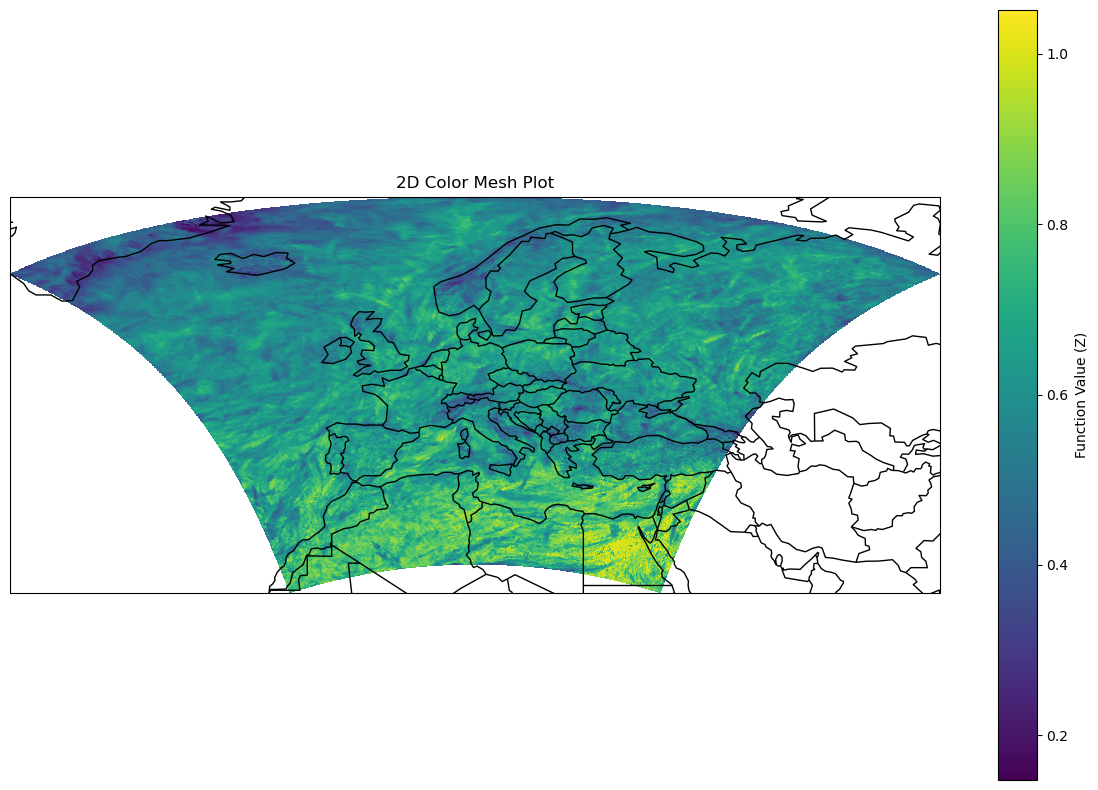

In [13]:
# 3. Create the color mesh plot
X = ds.lon
Y = ds.lat
Z = matrix_scale_parameter

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree()) # Or any other suitable projection
mesh = ax.pcolormesh(X, Y, Z, cmap='viridis') # 'viridis' is a common colormap
ax.add_feature(cfeature.BORDERS)
plt.colorbar(mesh, ax=ax, label='Function Value (Z)') # Add a colorbar to interpret colors
plt.title('2D Color Mesh Plot')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')

# Add coastlines to the GeoAxes
ax.coastlines()

plt.grid(True)
plt.show()